Exploratory Data Analysis

In [2]:
#Import neccessary libraries 
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Import geopandas as gpd to create the map

import geopandas as gpd

In [4]:
#Create a reference table that includes population, total number of crimes, crimes per x people and average property price per reigon

#Information about populationa and property price taken from external data sources and stored in new dataframe
population = [1188090, 1175364, 669380, 15111, 1248649]
avg_property_price = [214393, 712600, 343282, 934788, 584320]
labels = ["Nottinghamshire Police","Leicestershire Police","Gloucestershire Constabulary","City of London Police","Surrey Police"]

reference_df = pd.DataFrame({'Population': population,'Average Property Price': avg_property_price}, index=labels)

#Display
reference_df

,Population,Average Property Price
Nottinghamshire Police,1188090,214393
Leicestershire Police,1175364,712600
Gloucestershire Constabulary,669380,343282
City of London Police,15111,934788
Surrey Police,1248649,584320


In [5]:
#Import clean dataset
path = r"C:\Users\melpa\OneDrive\My Documents\Crime Analysis Project\data\processed\Clean_street_analysis.csv"
df=pd.read_csv(path)
df.head()

,Unnamed: 0,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,0,e7b720d0e1302d2d06db7b28b29132eb194864d44d7921...,2024-01,City of London Police,City of London Police,-0.10622,51.518275,On or near B500,E01000916,Camden 027B,Theft from the person,Investigation complete; no suspect identified
1,1,e60a5ac62a80e866453254474137c3206417422c62f0c0...,2024-01,City of London Police,City of London Police,-0.107682,51.517786,On or near B521,E01000917,Camden 027C,Other theft,Investigation complete; no suspect identified
2,2,986f618142ec52b7f254e4b0549da2f17ceeb0e130db6c...,2024-01,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Other theft,Investigation complete; no suspect identified
3,3,05dc27a88748356f6d59b0bd1389710ebfb42b37e565af...,2024-01,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Theft from the person,Status update unavailable
4,4,373d78e2ccec5d05a547cd4bee19045a9e050042a0e6e7...,2024-01,City of London Police,City of London Police,-0.112096,51.515942,On or near Nightclub,E01000914,Camden 028B,Theft from the person,Investigation complete; no suspect identified


In [6]:
#Total number of crimes per police force area
number_of_crimes = df['Falls within'].value_counts()
number_of_crimes

Falls within
Nottinghamshire Police          240330
Leicestershire Police           215503
Surrey Police                   175447
Gloucestershire Constabulary    115276
City of London Police            19403
Name: count, dtype: int64

In [7]:
#create new column storing total crimes
reference_df["Total number of crimes"] = number_of_crimes
reference_df

,Population,Average Property Price,Total number of crimes
Nottinghamshire Police,1188090,214393,240330
Leicestershire Police,1175364,712600,215503
Gloucestershire Constabulary,669380,343282,115276
City of London Police,15111,934788,19403
Surrey Police,1248649,584320,175447


In [8]:
#Working out crimes per 1000 people to standardise comparison of crimes commited in each region
reference_df['Crime per 1000'] = (reference_df['Total number of crimes']/reference_df['Population'])*1000
reference_df

,Population,Average Property Price,Total number of crimes,Crime per 1000
Nottinghamshire Police,1188090,214393,240330,202.282655
Leicestershire Police,1175364,712600,215503,183.350009
Gloucestershire Constabulary,669380,343282,115276,172.213093
City of London Police,15111,934788,19403,1284.031500
Surrey Police,1248649,584320,175447,140.509463


Data Visualisation

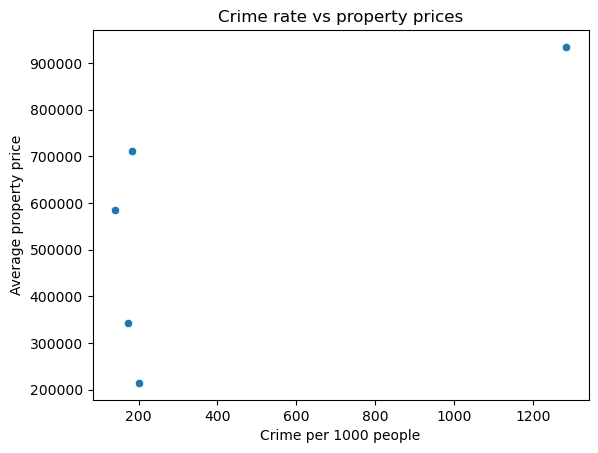

In [9]:
#Scatterplot to compare avergae property prices and crime levels
sns.scatterplot(
    data=reference_df,
    x='Crime per 1000',
    y='Average Property Price'
)

plt.title('Crime rate vs property prices')
plt.xlabel('Crime per 1000 people')
plt.ylabel('Average property price')
plt.show()

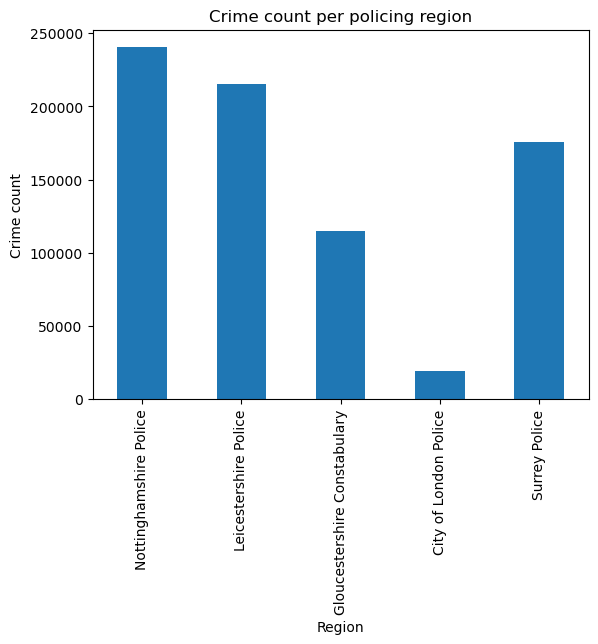

In [10]:
#Graph to compare total number of crimes between police force regions
reference_df['Total number of crimes'].plot(kind="bar")

plt.xlabel("Region")
plt.ylabel("Crime count")
plt.title("Crime count per policing region")

plt.xticks(rotation=90)
plt.show()

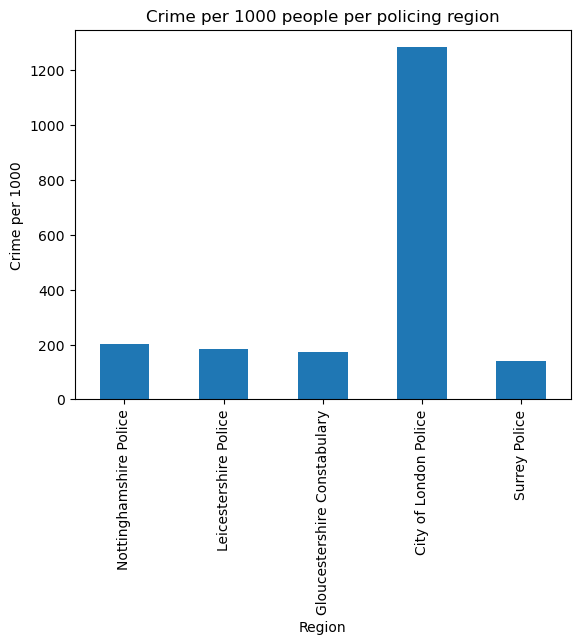

In [11]:
#Graph to compare crimes per 1000 people between police force regions
reference_df['Crime per 1000'].plot(kind="bar")

plt.xlabel("Region")
plt.ylabel("Crime per 1000")
plt.title("Crime per 1000 people per policing region")

plt.xticks(rotation=90)
plt.show()

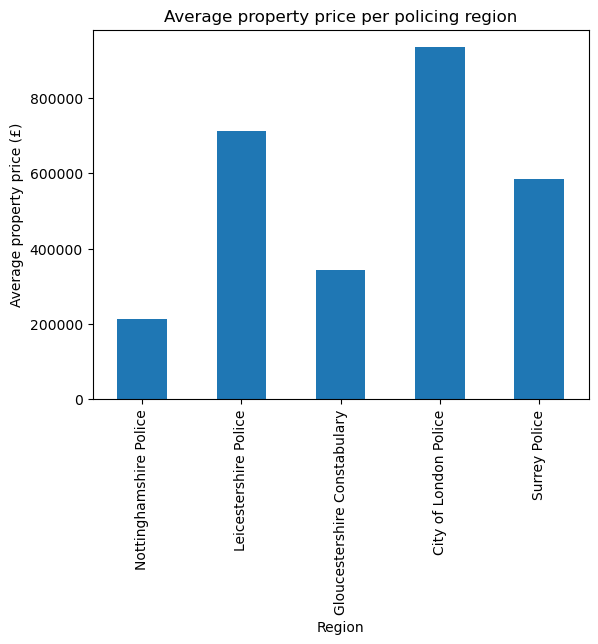

In [12]:
#Graph to compare the average propert prices between policing regions
reference_df['Average Property Price'].plot(kind="bar")

plt.xlabel("Region")
plt.ylabel("Average property price (£)")
plt.title("Average property price per policing region")

plt.xticks(rotation=90)
plt.show()

In [13]:
#Grouping all dates toghether for each region with the number of crimes committed
crime_trends = df.groupby(['Month', 'Falls within']).size().reset_index(name="Total number of crimes")
crime_trends

,Month,Falls within,Total number of crimes
0,2024-01,City of London Police,730
1,2024-01,Gloucestershire Constabulary,4852
2,2024-01,Leicestershire Police,8199
3,2024-01,Nottinghamshire Police,9458
4,2024-01,Surrey Police,6951
...,...,...,...
120,2026-01,City of London Police,708
121,2026-01,Gloucestershire Constabulary,4121
122,2026-01,Leicestershire Police,7768
123,2026-01,Nottinghamshire Police,9760


In [14]:
#Creating a pivot table for the information
crime_trends_pivot = crime_trends.pivot(
    index='Month',
    columns='Falls within',
    values='Total number of crimes')

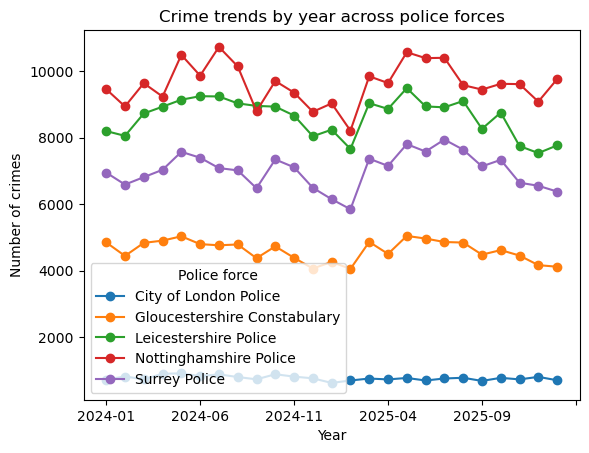

In [15]:
#Line graph to show crime over the time period
crime_trends_pivot.plot(marker="o")

plt.title("Crime trends by year across police forces")
plt.xlabel("Year")
plt.ylabel("Number of crimes")

plt.legend(title="Police force")
plt.show()

In [16]:
#Grouping crimes together depening on which type they fall under
crime_types = df.groupby(["Falls within", "Crime type"]).size().reset_index(name="Count")

<Axes: xlabel='Count', ylabel='Crime type'>

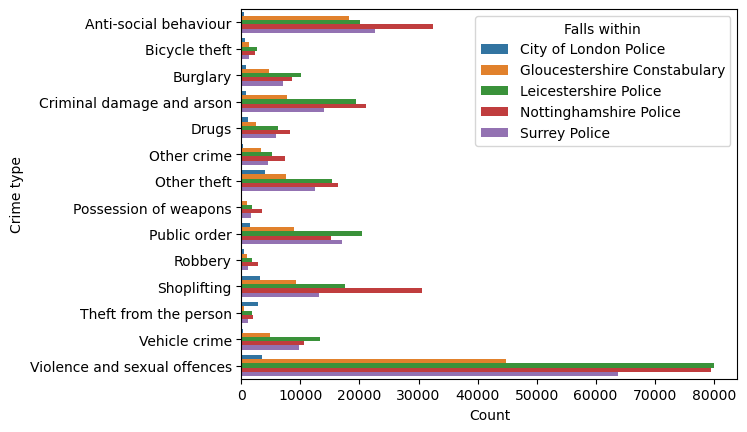

In [17]:
sns.barplot(
    data=crime_types,
    x="Count",
    y="Crime type",
    hue="Falls within"
)

In [18]:
#Top type of crimes commited across all police forces
df["Falls within"].value_counts()
df["Crime type"].value_counts().head(10)

Crime type
Violence and sexual offences    271571
Anti-social behaviour            93724
Shoplifting                      73495
Public order                     63006
Criminal damage and arson        62942
Other theft                      55723
Vehicle crime                    38515
Burglary                         31251
Drugs                            23915
Other crime                      20672
Name: count, dtype: int64

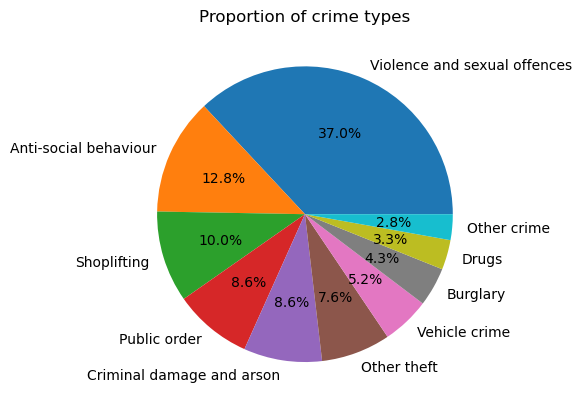

In [19]:
crime_types = df["Crime type"].value_counts().head(10)

crime_types.plot(kind="pie", autopct="%1.1f%%")
plt.title("Proportion of crime types")
plt.ylabel("")
plt.show()

<Axes: xlabel='Falls within'>

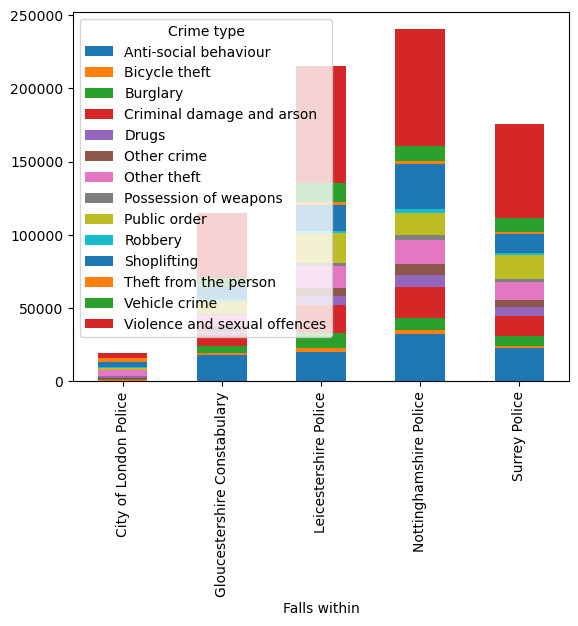

In [20]:

crime_stacked = df.groupby(["Falls within","Crime type"]).size().unstack()
crime_stacked.plot(kind="bar", stacked=True)

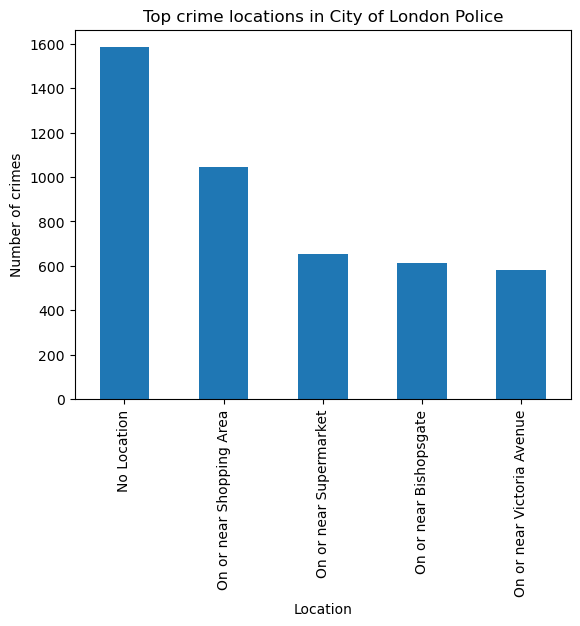

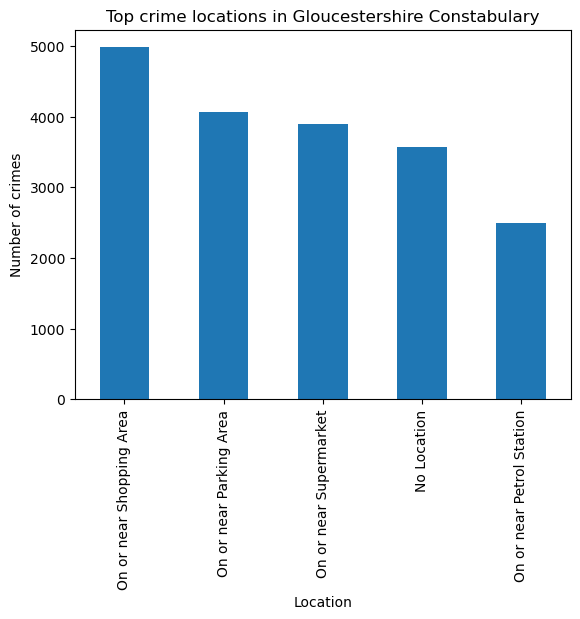

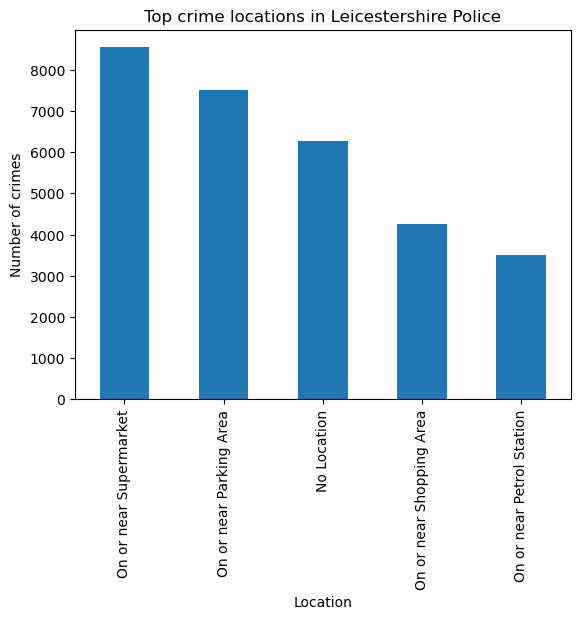

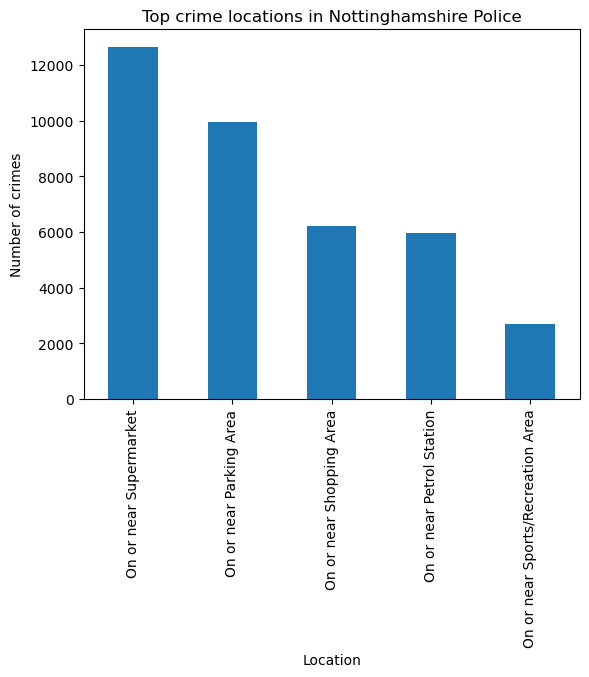

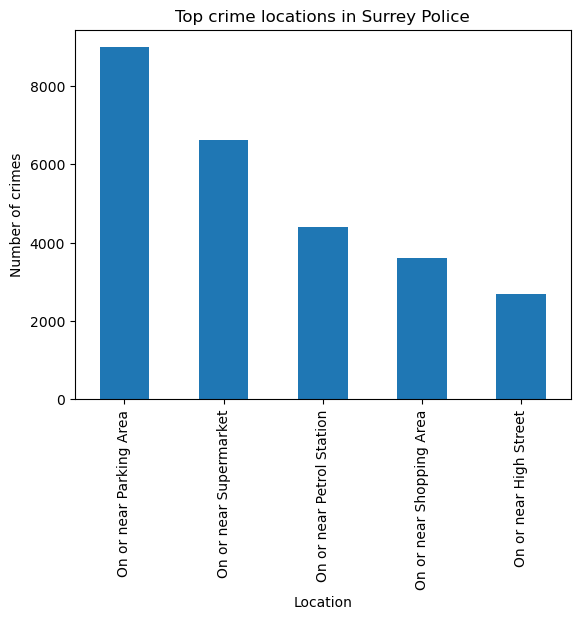

In [21]:
forces = df["Falls within"].unique()

for force in forces:
    subset = df[df["Falls within"] == force]
    location_counts = subset["Location"].value_counts().head(5)

    location_counts.plot(kind="bar")
    plt.title(f"Top crime locations in {force}")
    plt.xlabel("Location")
    plt.ylabel("Number of crimes")
    plt.xticks(rotation=90)
    plt.show()

<Axes: xlabel='Falls within', ylabel='Crime type'>

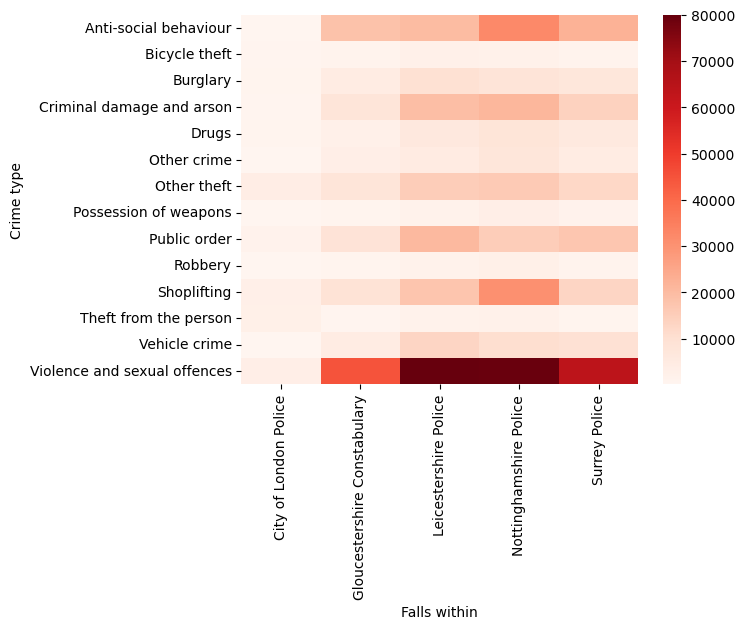

In [22]:
crime_heatmap = df.pivot_table(
    index="Crime type",
    columns="Falls within",
    aggfunc="size"
)

sns.heatmap(crime_heatmap, cmap="Reds")

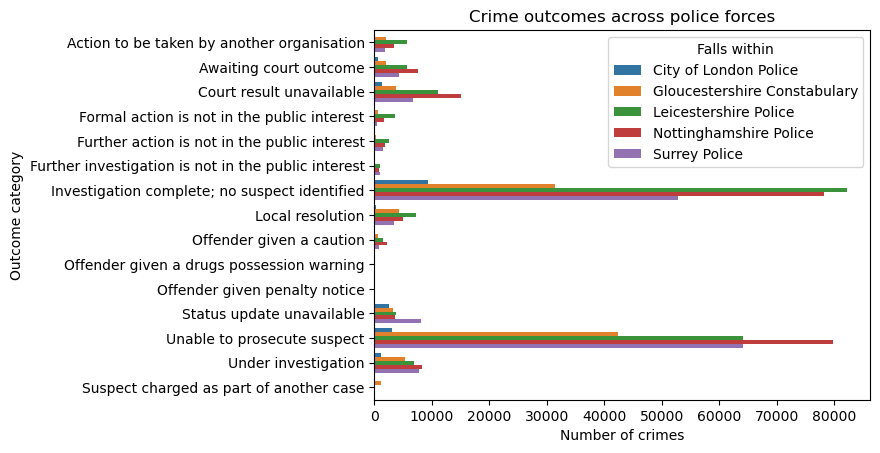

In [23]:
outcome_counts = df.groupby(["Falls within","Last outcome category"]).size().reset_index(name="Count")

sns.barplot(
    data=outcome_counts,
    x="Count",
    y="Last outcome category",
    hue="Falls within"
)

plt.title("Crime outcomes across police forces")
plt.xlabel("Number of crimes")
plt.ylabel("Outcome category")
plt.show()

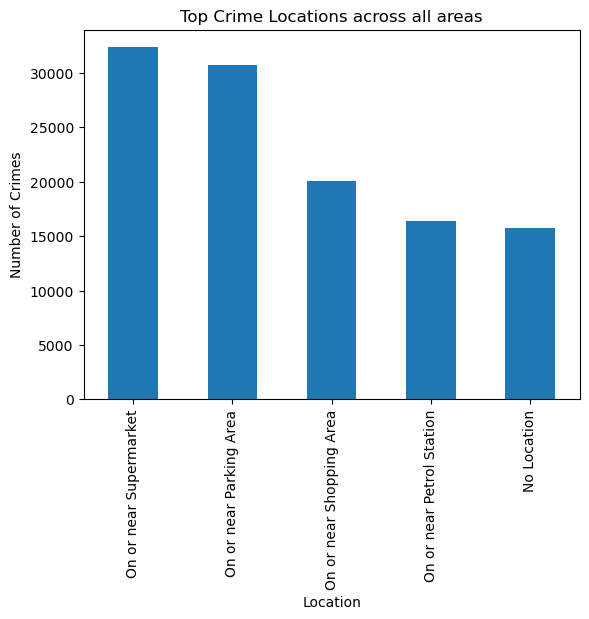

In [24]:
location_counts = df["Location"].value_counts().head(5)
import matplotlib.pyplot as plt

location_counts.plot(kind="bar")

plt.title("Top Crime Locations across all areas")
plt.xlabel("Location")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=90)

plt.show()

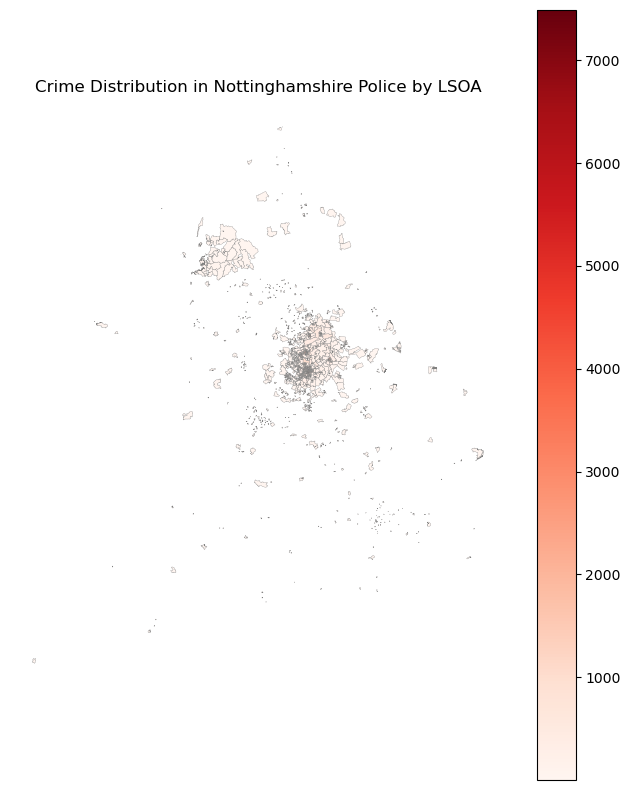

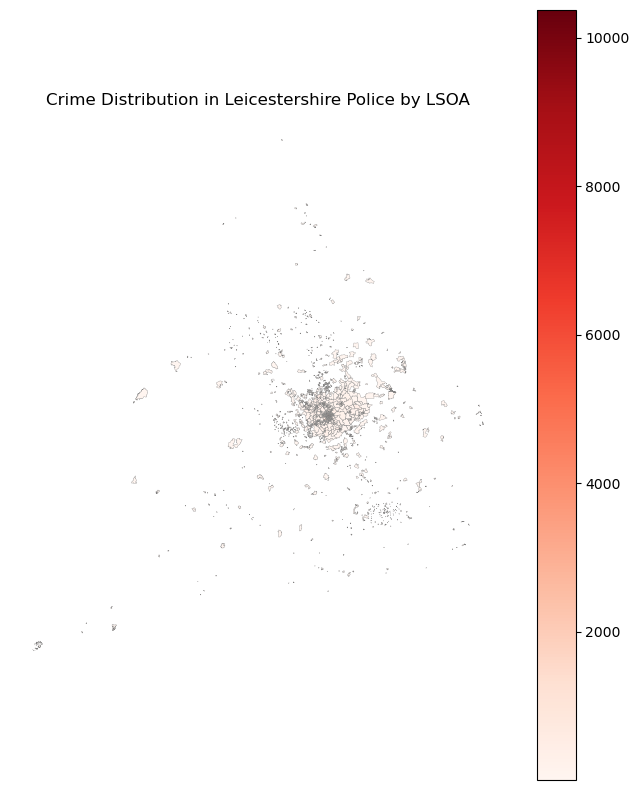

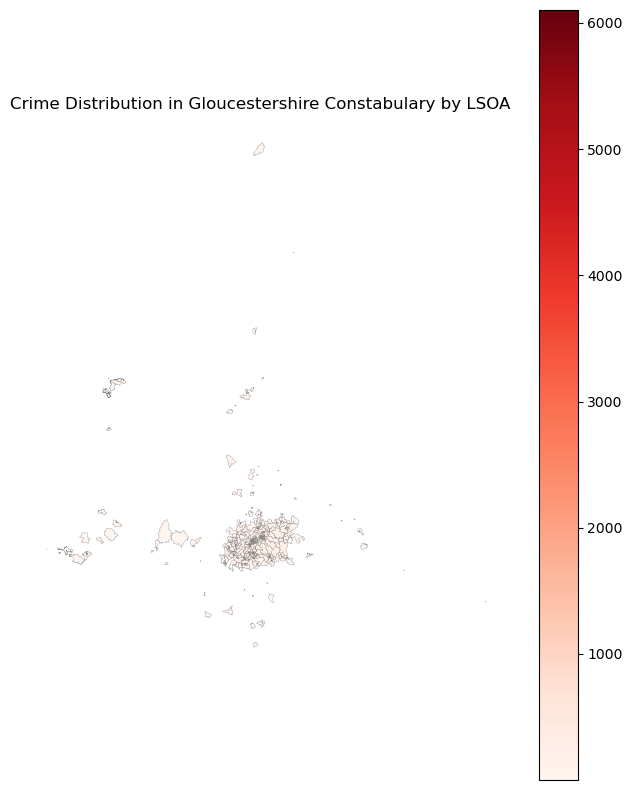

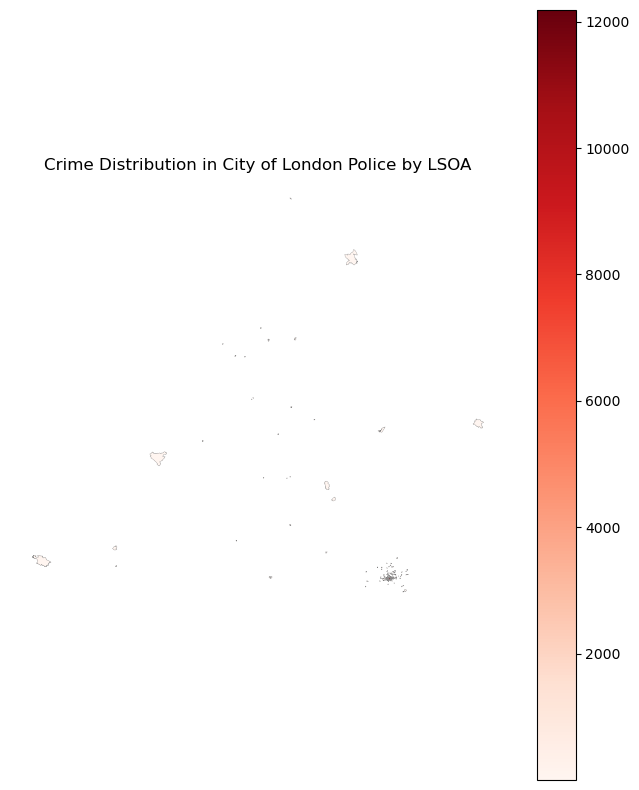

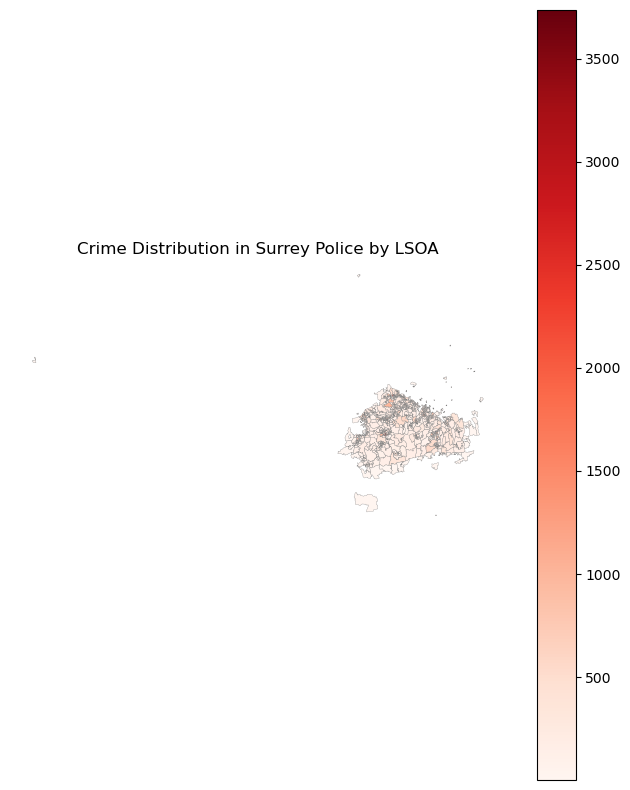

In [26]:

lsoa_map = gpd.read_file(
    r"C:\Users\melpa\OneDrive\My Documents\Crime Analysis Project\data\Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BFC_V10_-7599572456947714539\LSOA_2021_EW_BFC_V10.shp"
)

# make sure LSOA codes are strings and remove any extra spaces
df["LSOA code"] = df["LSOA code"].astype(str).str.strip()
lsoa_map["LSOA21CD"] = lsoa_map["LSOA21CD"].astype(str).str.strip()

# list of police forces to map
forces = [
    "Nottinghamshire Police",
    "Leicestershire Police",
    "Gloucestershire Constabulary",
    "City of London Police",
    "Surrey Police"
]

# loop through each police force
for force in forces:
    
    # filter crime data for one police force
    force_df = df[df["Falls within"] == force]
    
    # count crimes by LSOA
    lsoa_counts = force_df["LSOA code"].value_counts().reset_index()
    lsoa_counts.columns = ["LSOA code", "Crime_count"]
    
    # get only the LSOA codes for that police force
    force_codes = lsoa_counts["LSOA code"]
    
    # filter shapefile to only those LSOAs
    force_map = lsoa_map[lsoa_map["LSOA21CD"].isin(force_codes)]
    
    # merge crime counts onto filtered map
    map_df = force_map.merge(
        lsoa_counts,
        left_on="LSOA21CD",
        right_on="LSOA code"
    )
    
    # plot map
    fig, ax = plt.subplots(figsize=(8, 10))
    
    map_df.plot(
        column="Crime_count",
        cmap="Reds",
        legend=True,
        linewidth=0.2,
        edgecolor="grey",
        ax=ax
    )
    
    ax.set_title(f"Crime Distribution in {force} by LSOA")
    ax.axis("off")
    
    plt.show()